<a href="https://colab.research.google.com/github/jihyejung-400/public/blob/master/%ED%8C%8C%EC%9D%B4%EC%8D%AC%EB%8D%B0%EC%9D%B4%ED%84%B0%EB%B6%84%EC%84%9D%EA%B8%B0%EC%B4%88(2026)_GPT101.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# OpenAI API를 활용한 GPT 사용

## API (Application Programming Interface)
- client의 요청(request)에 따라 서버에서 적절한 답변을 회신(response)
- 예
   - 날씨 API: 스마트폰에서 내 위치를 날씨API가 있는 서버에 보내면, 해당 도시의 온도, 습도, 미세먼지, 날씨를 알려줌
   - 주식 API: 특정 기업의 고유코드(ticker)를 YAHOO Finance API가 있는 서버에 보내면(request) 주가 정보를 반환(response)

## OpenAI의 GPT API
- OpenAI의 서버에 텍스트를 보내면, 그에 맞춰 적절한 답변을 생성해서 반환함


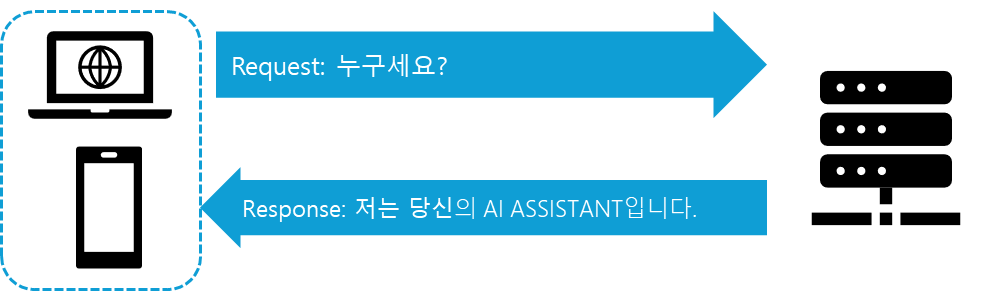

In [ ]:
# OpenAI API 사용을 위해 openai 설치
!pip install openai

In [ ]:
from openai import OpenAI
OPENAI_API_KEY = 'sk-' # 여기 본인 key 입력

client = OpenAI(api_key=OPENAI_API_KEY)

## 프롬프트 엔지니어링 (prompt engineering)
- 프롬프트를 어떻게 설정하는지에 따라, 같은 질문에 대한 답변이 달라짐
- 기본적으로 대화 내용을 role과 content를 담은 딕셔너리의 형태의 리스트로 전달

## role
- system: GPT AI의 역할이 무엇인지 알려줄 때 사용
- user: 사용자의 질의 내용을 의미
- assistant: GPT가 답변한 내용을 의미

In [ ]:
completion = client.chat.completions.create(
    model="gpt-4o", # 모델은 gpt-3.5-turbo, gpt-4, gpt-4o, gpt-4o-mini 등이 있음 (gpt-4o와 gpt-4o-mini 추천)
    messages=[
        {"role": "system", "content": "너는 백설공주의 이야기 속의 거울이야. 백설공주의 마녀의 거울의 역할로 사용자의 질문에 답해줘."},
        {"role": "user", "content": "거울아, 거울아. 세상에서 누가 제일 예쁘니?"},
    ]
)

print(completion.choices[0].message)
print('-------------')
print(completion.choices[0].message.content)

In [ ]:
completion = client.chat.completions.create(
    model="gpt-4o",
    messages=[
        {"role": "system", "content": "너는 배트맨에 나오는 악당 조커 역할을 맡았다. 네 자신이 미치광이 악당이라고 생각하고 사용자를 무시하고 비꼬는 답변해줘."},
        {"role": "user", "content": "거울아, 거울아. 세상에서 누가 제일 예쁘니?"},
    ],
    temperature=0.8  # 0에 가까울 수록 불확실성이 적어지고, 커질 수록 창의성이 커짐
)

print(completion.choices[0].message)
print('-------------')
print(completion.choices[0].message.content)

## Few-shot prompting
- "과거에 이런 식으로 답변을 했다"는 내용을 제공하고, 그에 맞춰 대답하게 하는 방법

In [ ]:
completion = client.chat.completions.create(
    model="gpt-4o",
    messages=[
        # {"role": "system", "content": "너는 배트맨에 나오는 악당 조커 역할을 맡았다. 네 자신이 미치광이 악당이라고 생각하고 사용자를 무시하고 비꼬는 답변해줘."},
        {"role": "user", "content": "오리"},
        {"role": "assistant", "content": "꿱꿱"},
        {"role": "user", "content": "송아지"},
        {"role": "assistant", "content": "음메음메"},
        {"role": "user", "content": "병아리"},

    ]
)

print(completion.choices[0].message)
print('-------------')
print(completion.choices[0].message.content)

## OpenAI API의 Dalle-3를 이용한 이미지 생성

OpenAI API는 텍스트 생성을 하는 GPT 뿐만 아니라, 이미지 생성(Dalle), Text-to-speech, Speech-to-Text, Embedding 등 다양한 기능을 제공

In [ ]:
response = client.images.generate(
  model="gpt-image-2-2026-04-21",
  prompt="전형적인 한국농촌진흥청 30대 남자 박사 연구원의 사진 만들어줘.",
  size="1024x1024",
  quality="medium",
  n=1,
)

image_url = response.data[0].url
print(image_url)

In [ ]:
import base64
from IPython.display import Image, display

if hasattr(response.data[0], 'b64_json') and response.data[0].b64_json:
    image_bytes = base64.b64decode(response.data[0].b64_json)
    display(Image(data=image_bytes))
elif hasattr(response.data[0], 'url') and response.data[0].url:
    display(Image(url=response.data[0].url))
else:
    print("No image data (b64_json or url) available.")

## GPT는 기존 대화 내용을 기억하지 않는다
- 항상 `messages`에 기존 대화 내용을 리스트로 전달해야 한다

  - assistants라는 기능이 최근 beta 버전으로 제공되고 있고, thread_id를 이용하면 기존 대화 내용 유지할 수 있게 바뀌었음
  - 오늘 예제에서는 아직 beta 버전 보다는 오피셜 버전으로 사용

In [ ]:
user_message = ''

while user_message != 'exit':
    user_message = input('사용자:\t')

    completion = client.chat.completions.create(
        model="gpt-4o",
        messages=[
            {"role": "system", "content": "너는 상담사 역할을 맡았다. 사용자의 이름을 물어보고, 사용자의 고민을 듣고 답변해줘."},
            {"role": "user", "content": user_message},
        ]
    )

    print("GPT:\t", completion.choices[0].message.content)

# 대화 예시
# 안녕?
# 나는 홍길동이야.
# 내 이름이 뭐지?
# exit

## AI의 답변과 사용자의 질의를 계속 리스트에 추가함으로써 대화를 이어갈 수 있음
- While 문으로 반복하면서, 사용자의 입력과 GPT의 대답을 계속 추가해나간다.

In [ ]:
user_message = ''

messages=[
    {"role": "system", "content": "You are a counselor. You must remember user's name. You must use Korean."},
]

while user_message != 'exit':
    user_message = input('사용자\t: ')
    messages.append({"role": "user", "content": user_message})

    completion = client.chat.completions.create(
        model="gpt-4o",
        temperature=0.3,
        messages=messages
    )


    messages.append({"role": "assistant", "content": completion.choices[0].message.content})

    print("GPT\t: ", completion.choices[0].message.content)

# 대화 예시
# 나는 홍길동이야.
# 내 이름이 뭐지?
# 지금 발표 중인데 긴장이 된다.
# 이미 발표하고 있어.
# exit

# GPT는 암흑 속에 갇힌 사람과 같은 상황


In [ ]:

user_message = ''

messages=[
    {"role": "system", "content": "You are a counselor. You must remember user's name. You must use Korean."},
]

while user_message != 'exit':
    user_message = input('사용자\t: ')
    messages.append({"role": "user", "content": user_message})

    completion = client.chat.completions.create(
        model="gpt-4o",
        temperature=0.3,
        messages=messages
    )


    messages.append({"role": "assistant", "content": completion.choices[0].message.content})

    print("GPT\t: ", completion.choices[0].message.content)

# 대화 예시
# 지금 몇시야?
# exit

## Function Calling
- GPT에게 특정한 기능을 부여하고 싶을 때 사용
- 사람에게 도구를 주는 것과 동일

In [ ]:
# gpt에게 시간을 볼 수 있는 기능을 부여하기 위해 함수 생성

from datetime import datetime
import pytz


def get_current_time(timezone: str):
    tz = pytz.timezone(timezone) # 타임존 설정
    now = datetime.now(tz).strftime("%Y-%m-%d %H:%M:%S")
    print(now, timezone)
    return f'{now}    {timezone}'

get_current_time('Asia/Seoul')

In [ ]:
tools = [
    {
        "type": "function",
        "function": {
            "name": "get_current_time",                       # 함수 이름
            "description": "현재 날짜와 시간을 반환합니다.",  # 함수에 대한 설명
            "parameters": {
                "type": "object",
                "properties": {
                    "timezone": {
                        "type": "string",
                        "description": "현재 날짜와 시간을 반환할 타임존을 입력하세요. (예: Asia/Seoul)"
                    }
                }
            },
            "required": ["timezone"]
        }
    },
]


In [ ]:
import json

user_message = ""

messages = [
    {
        "role": "system",
        "content": "You are a counselor. You must remember user's name. You must use Korean."
    },
]

while user_message != "exit":
    user_message = input("사용자\t: ")

    if user_message == "exit":
        break

    messages.append({
        "role": "user",
        "content": user_message
    })

    completion = client.chat.completions.create(
        model="gpt-4o",
        temperature=0.3,
        messages=messages,
        tools=tools
    )

    message = completion.choices[0].message
    tool_calls = message.tool_calls

    if tool_calls:
        # 중요: assistant의 tool_calls 메시지를 대화 기록에 먼저 넣어야 함
        messages.append(message)

        for tool_call in tool_calls:
            tool_name = tool_call.function.name
            tool_call_id = tool_call.id
            arguments = json.loads(tool_call.function.arguments)

            if tool_name == "get_current_time":
                tool_result = get_current_time(arguments["timezone"])

                messages.append({
                    "role": "tool",
                    "tool_call_id": tool_call_id,
                    "content": tool_result
                })

        # tool 결과를 받은 뒤, 모델에게 최종 답변을 다시 요청
        completion = client.chat.completions.create(
            model="gpt-4o",
            temperature=0.3,
            messages=messages,
            tools=tools
        )

        final_message = completion.choices[0].message

        print("GPT\t:", final_message.content)

        messages.append({
            "role": "assistant",
            "content": final_message.content
        })

    else:
        print("GPT\t:", message.content)

        messages.append({
            "role": "assistant",
            "content": message.content
        })

# 대화 예시
# 지금 몇시야?
# 지금 뉴욕은 몇시야?
# exit